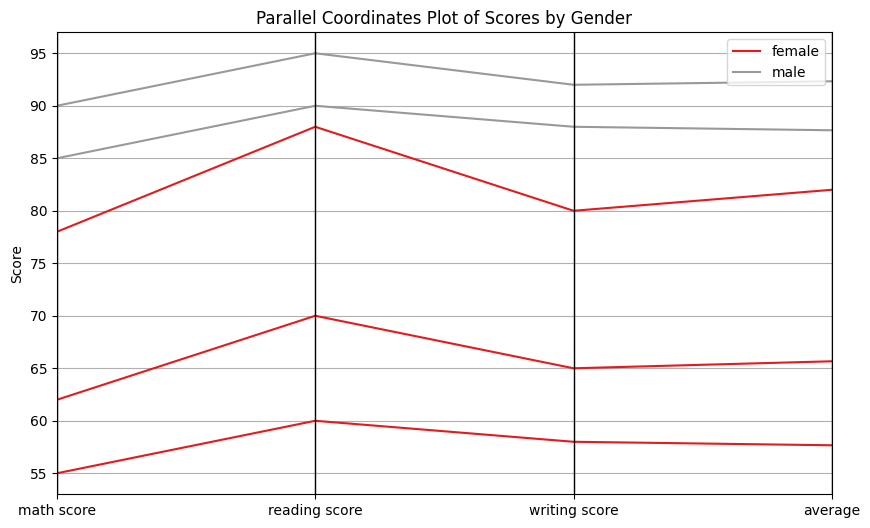

In [4]:
#1. Parallel Coordinates Plot
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

# Create sample data
data = {
    'math score': [78, 85, 62, 90, 55],
    'reading score': [88, 90, 70, 95, 60],
    'writing score': [80, 88, 65, 92, 58],
    'gender': ['female', 'male', 'female', 'male', 'female']
}
df = pd.DataFrame(data)

# Create subset and average
df_subset = df[['math score', 'reading score', 'writing score', 'gender']].copy()
df_subset['average'] = df_subset[['math score', 'reading score', 'writing score']].mean(axis=1)

# Plot
plt.figure(figsize=(10, 6))
parallel_coordinates(df_subset, class_column='gender', colormap='Set1')
plt.title("Parallel Coordinates Plot of Scores by Gender")
plt.ylabel("Score")
plt.grid(True)
plt.show()


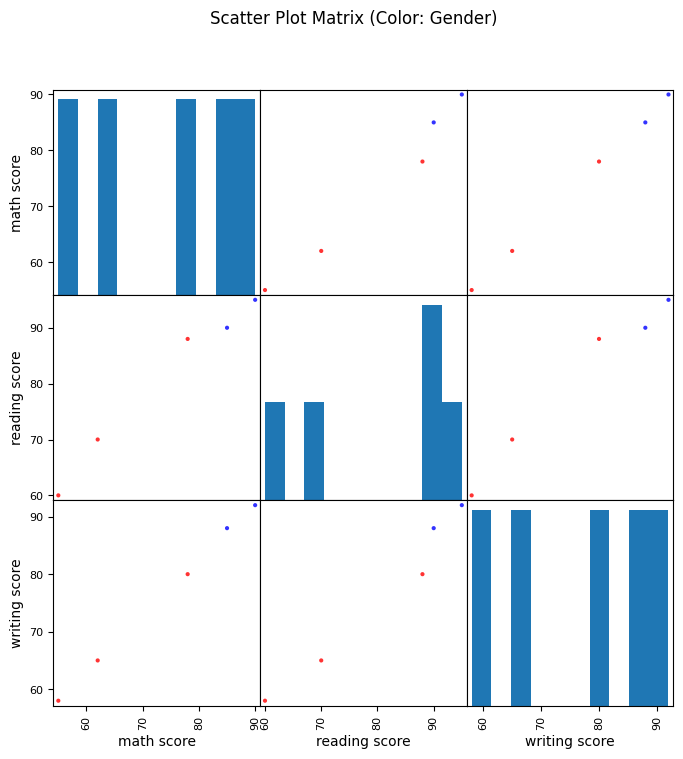

In [5]:
#2. Scatter Plot Matrix (Pandas)
from pandas.plotting import scatter_matrix

# Encode gender numerically for color
colors = df['gender'].map({'female': 'red', 'male': 'blue'})

scatter_matrix(df[['math score', 'reading score', 'writing score']], figsize=(8, 8), alpha=0.8, color=colors)
plt.suptitle("Scatter Plot Matrix (Color: Gender)")
plt.show()



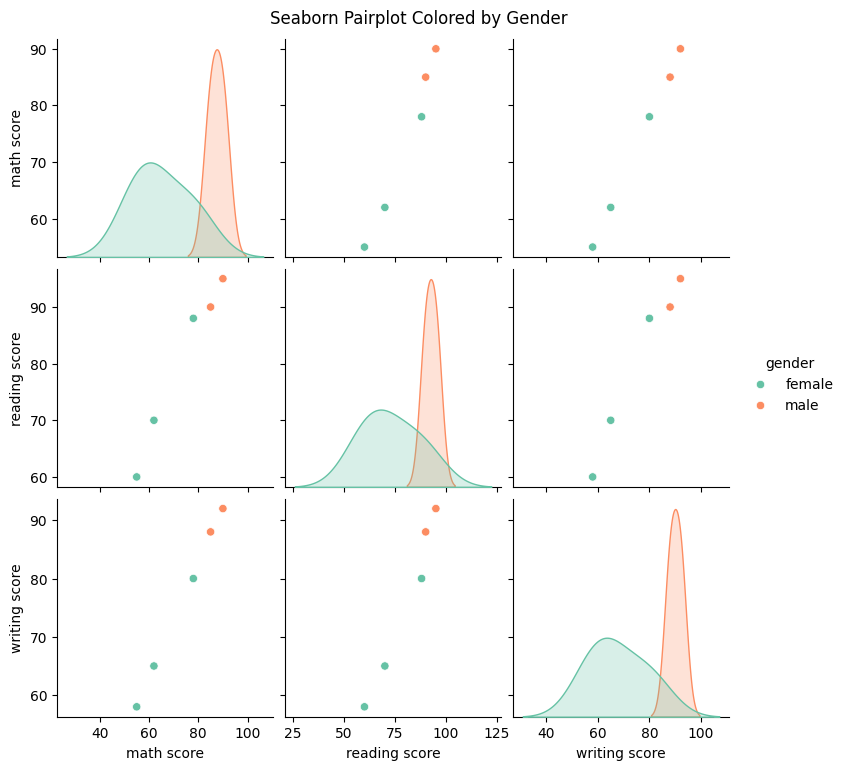

In [7]:
#3. Seaborn Pairplot
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df[['math score', 'reading score', 'writing score', 'gender']], hue='gender', palette='Set2')
plt.suptitle("Seaborn Pairplot Colored by Gender", y=1.02)
plt.show()


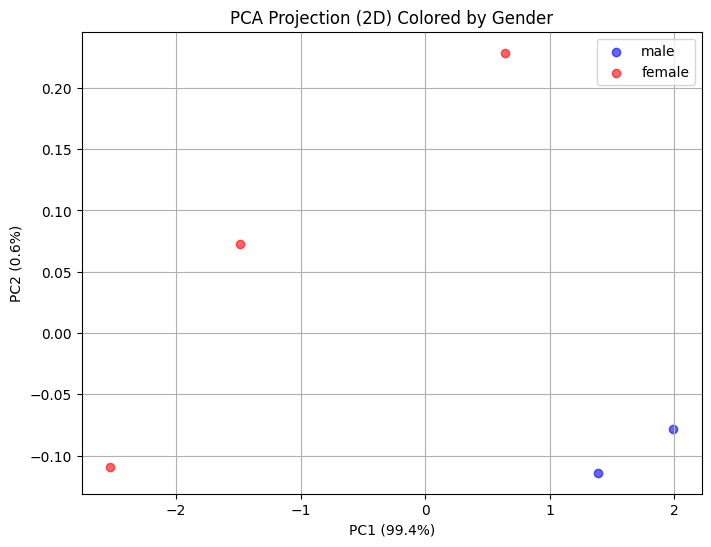

In [8]:
#4.  PCA Projection
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize features
X = df[['math score', 'reading score', 'writing score']]
X_std = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

# Plot PCA
plt.figure(figsize=(8,6))
for gender, color in zip(['male', 'female'], ['blue', 'red']):
    plt.scatter(X_pca[df['gender'] == gender, 0], X_pca[df['gender'] == gender, 1], label=gender, alpha=0.6, c=color)
    
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title("PCA Projection (2D) Colored by Gender")
plt.legend()
plt.grid(True)
plt.show()


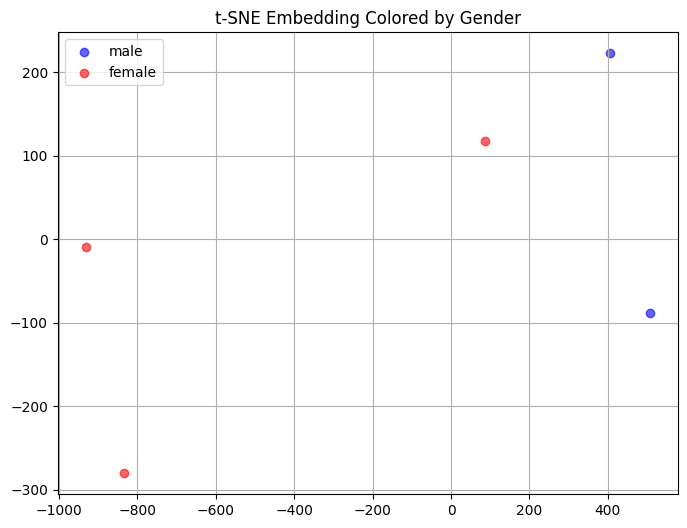

In [11]:
#5. t-SNE Embedding
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# Example data setup (replace with your real data)
# Assuming df has numeric columns 'math score', 'reading score', 'writing score' and 'gender'

features = ['math score', 'reading score', 'writing score']
X = df[features].values

# Standardize features
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=2, random_state=42)
X_tsne = tsne.fit_transform(X_std)


# Plot
plt.figure(figsize=(8,6))
for gender, color in zip(['male', 'female'], ['blue', 'red']):
    idx = df['gender'] == gender
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=gender, alpha=0.6, color=color)

plt.title("t-SNE Embedding Colored by Gender")
plt.legend()
plt.grid(True)
plt.show()

